In [2]:
# import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# read to be path
df_std = pd.read_csv(r"C:\Users\navne\Downloads\archive (4)\Student_Performance.csv")
df_std

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [3]:
# info
df_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [4]:
# descripation of Data
df_std.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [5]:
# check the nul Value
df_std.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
# Encoding Of data
df_std["Extracurricular Activities"] = np.where(df_std["Extracurricular Activities"].str.contains("Yes"),0,1)  
# values count of encoding
df_std["Extracurricular Activities"].value_counts()

Extracurricular Activities
1    5052
0    4948
Name: count, dtype: int64

In [7]:
# check the values
df_std.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,0,9,1,91.0
1,4,82,1,4,2,65.0
2,8,51,0,7,2,45.0
3,5,52,0,5,2,36.0
4,7,75,1,8,5,66.0


In [8]:
# speration of Data
x_data = df_std.iloc[:,:-1]
x_data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,0,9,1
1,4,82,1,4,2
2,8,51,0,7,2
3,5,52,0,5,2
4,7,75,1,8,5
...,...,...,...,...,...
9995,1,49,0,4,2
9996,7,64,0,8,5
9997,6,83,0,8,5
9998,9,97,0,7,0


In [9]:
y_data = df_std["Performance Index"]
y_data

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

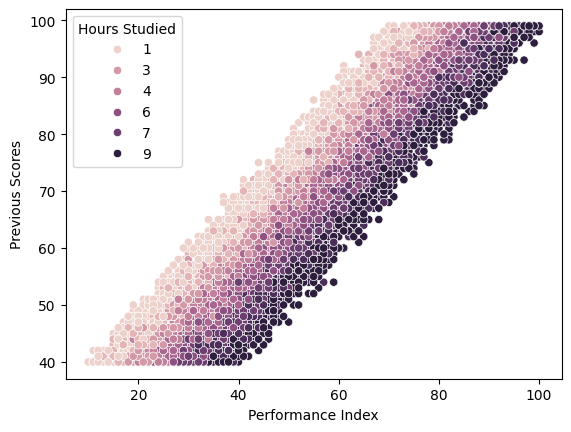

In [10]:
# scatter Data
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x = "Performance Index" ,y = "Previous Scores" ,hue = "Hours Studied", data = df_std)
plt.show()

In [11]:
# Train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_data,y_data ,test_size = 0.25,random_state = 42)

# shape of x_train and x_test
x_train.shape,x_test.shape

((7500, 5), (2500, 5))

In [12]:
# shape of y_train,y_test
y_train.shape,y_test.shape

((7500,), (2500,))

In [13]:
# Here Data Standardzation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# here Data fit of the Data scaler
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled

array([[ 0.00796272, -1.19062085,  0.98912579, -0.90874945,  0.13314392],
       [ 0.77854894,  1.05902612, -1.01099376, -1.49731775,  1.53122497],
       [-0.76262349,  1.40512565, -1.01099376,  0.26838714, -1.26493713],
       ...,
       [ 1.54913515, -1.24830411,  0.98912579,  0.26838714,  0.48266418],
       [-1.5332097 , -1.30598737,  0.98912579,  1.44552374, -1.6144574 ],
       [-1.14791659, -1.36367062,  0.98912579, -0.32018115,  0.48266418]],
      shape=(7500, 5))

## Linear Regression

In [14]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# fitting And transfromation of Data
lr.fit(x_train_scaled,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
# Score of train Data
lr.score(x_train_scaled,y_train)*100

98.86395368813106

In [16]:
# Score of test Data
lr.score(x_test_scaled,y_test)*100

98.90550757439104

In [17]:
y_pred = lr.predict(x_test_scaled)
y_pred

array([54.73187888, 22.61211054, 47.90838844, ..., 68.07396952,
       53.68636805, 54.85816372], shape=(2500,))

In [18]:
# cofficent
lr.coef_

array([ 7.40973867, 17.62000334, -0.29183721,  0.81024328,  0.54624431])

In [19]:
# intercept
lr.intercept_

np.float64(55.41839999999999)

<Figure size 3500x2500 with 0 Axes>

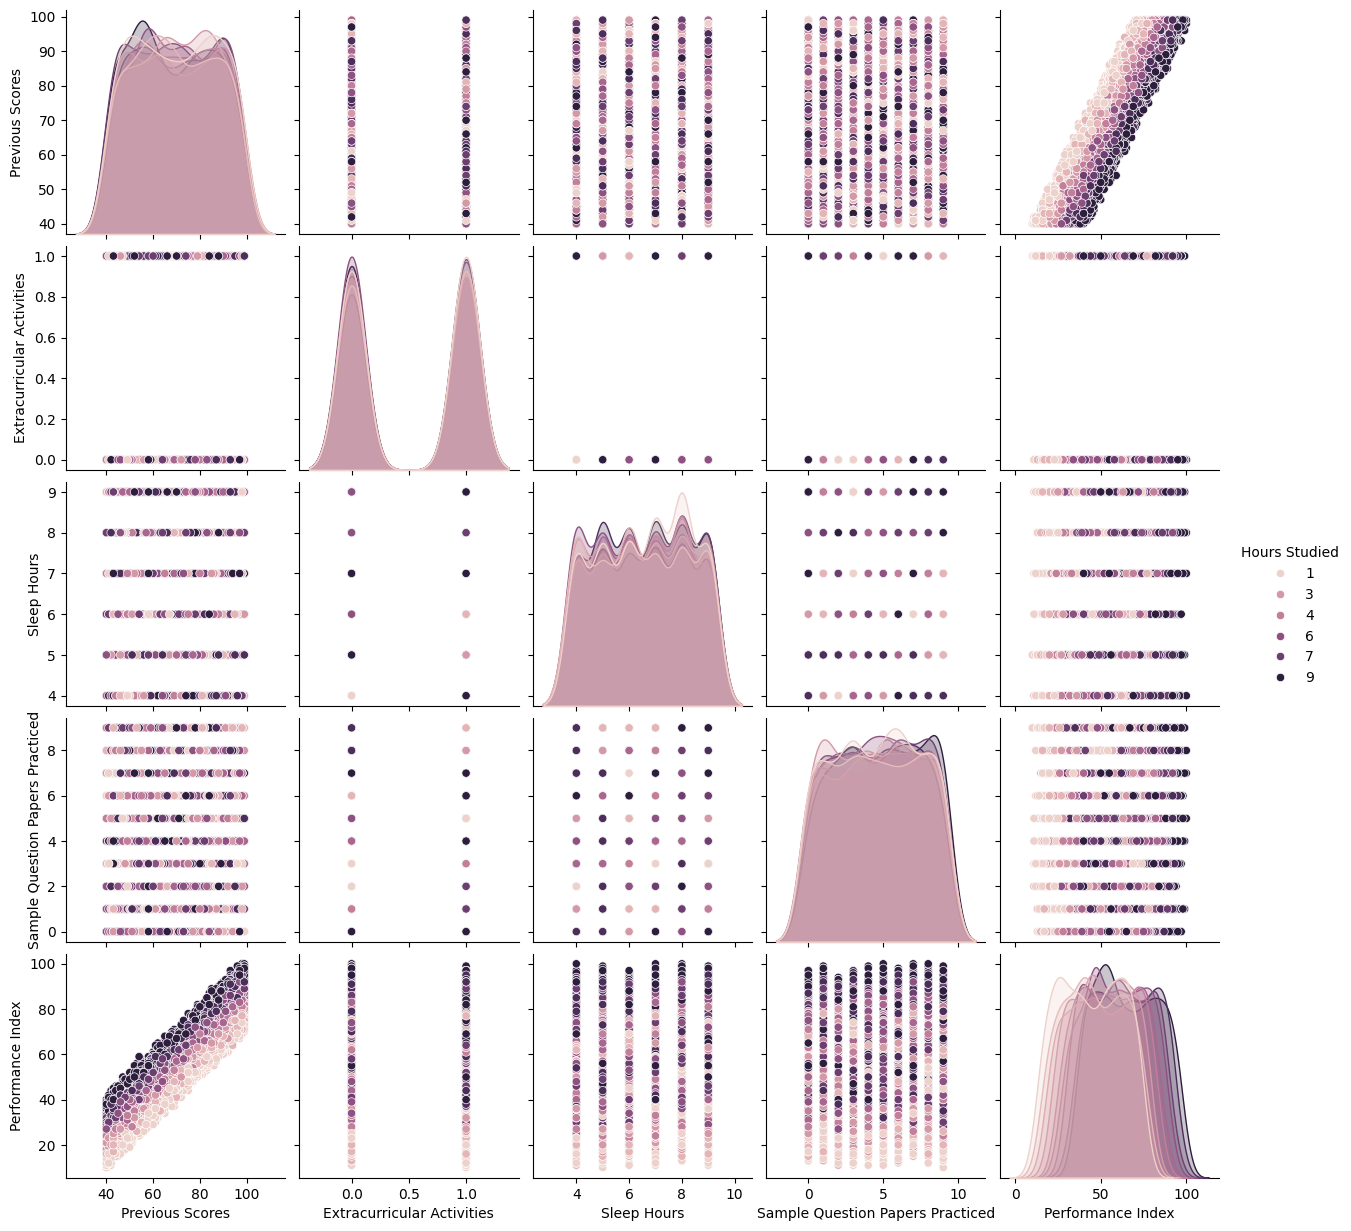

In [20]:
# pair plot of data
plt.figure(figsize = (35,25))
sns.pairplot(df_std,hue ="Hours Studied")
plt.show()


In [21]:
# here correlation
corr = df_std.corr()


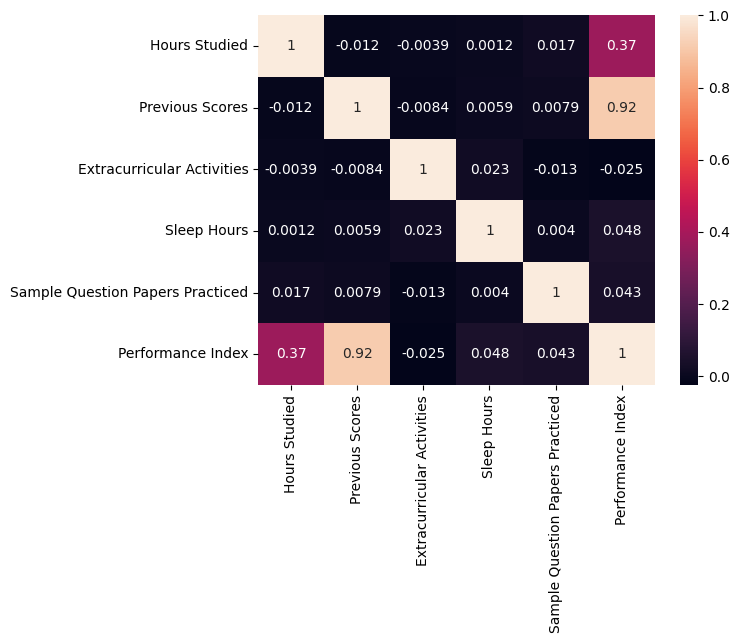

In [22]:
# heatmap 
sns.heatmap(df_std.corr(),annot = True)
plt.show()

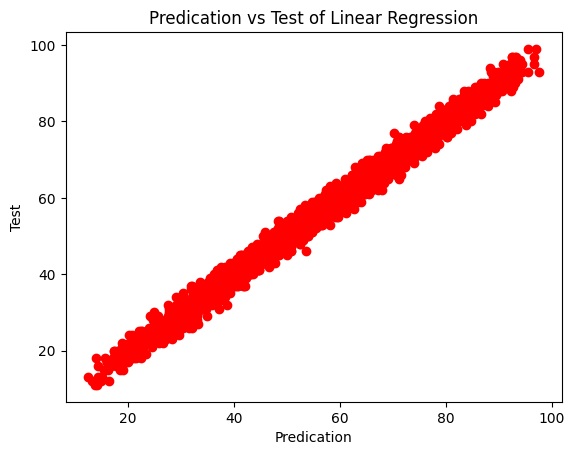

In [23]:
# scatter program
plt.scatter(y_pred,y_test,color = "red")
plt.xlabel("Predication")
plt.ylabel("Test")
plt.title("Predication vs Test of Linear Regression")
plt.show()


## Lassocv Cross Validation


In [25]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
lcv = LassoCV(cv = 5)
lcv.fit(x_train_scaled,y_train)
Y_pred = lcv.predict(x_test_scaled)
Y_pred

array([54.75066699, 22.64364155, 47.88366741, ..., 68.04432715,
       53.73399579, 54.87028003], shape=(2500,))

In [26]:
mae = mean_absolute_error(Y_pred,y_test)
mae

1.599182719482898

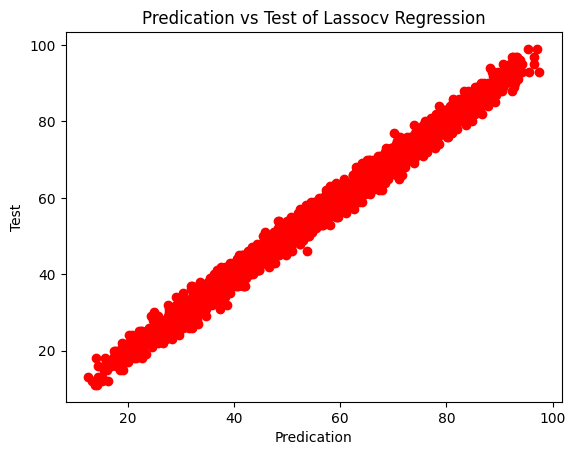

In [27]:
# scatter of Lassocv
plt.scatter(Y_pred,y_test,color = "red")
plt.xlabel("Predication")
plt.ylabel("Test")
plt.title("Predication vs Test of Lassocv Regression")
plt.show()

## Ridge Cross Validation

In [35]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
rcv = Ridge()
rcv.fit(x_train_scaled,y_train)
y1_pred = rcv.predict(x_test_scaled)
mae = mean_absolute_error(y1_pred,y_test)



In [ ]:
# Scatter plot
plt.scatter(y1_pred,